In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_10'

def load_judgements(arm):
    path = f'{RESULTS_DIR}/{arm}/judgements/three_languages.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms = {
    'arm_0': '(None, X + Y + Z)',
    'arm_1': '(X+, X + Y + Z)',
    'arm_2': '(Y+, X + Y + Z)',
    'arm_3': '(Z+, X + Y + Z)',
    'arm_4': '(X-, X + Y + Z)',
    'arm_5': '(Y-, X + Y + Z)',
    'arm_6': '(Z-, X + Y + Z)',
}

all_data = {}
all_summaries = {}
for arm in arms:
    all_data[arm], all_summaries[arm] = load_judgements(arm)
    s = all_summaries[arm]
    print(f"{arms[arm]}: spanish={s['mean_spanish_score']:.4f}, french={s['mean_french_score']:.4f}, german={s['mean_german_score']:.4f}")

Matplotlib is building the font cache; this may take a moment.


(None, X + Y + Z): spanish=18.3533, french=16.3990, german=30.3967
(X+, X + Y + Z): spanish=1.8203, french=33.9745, german=40.3759
(Y+, X + Y + Z): spanish=22.9724, french=3.1176, german=47.7241
(Z+, X + Y + Z): spanish=25.3541, french=43.2282, german=8.1174
(X-, X + Y + Z): spanish=15.1747, french=25.2899, german=41.0931
(Y-, X + Y + Z): spanish=38.4566, french=8.2805, german=36.9866
(Z-, X + Y + Z): spanish=24.8296, french=43.3144, german=12.0953


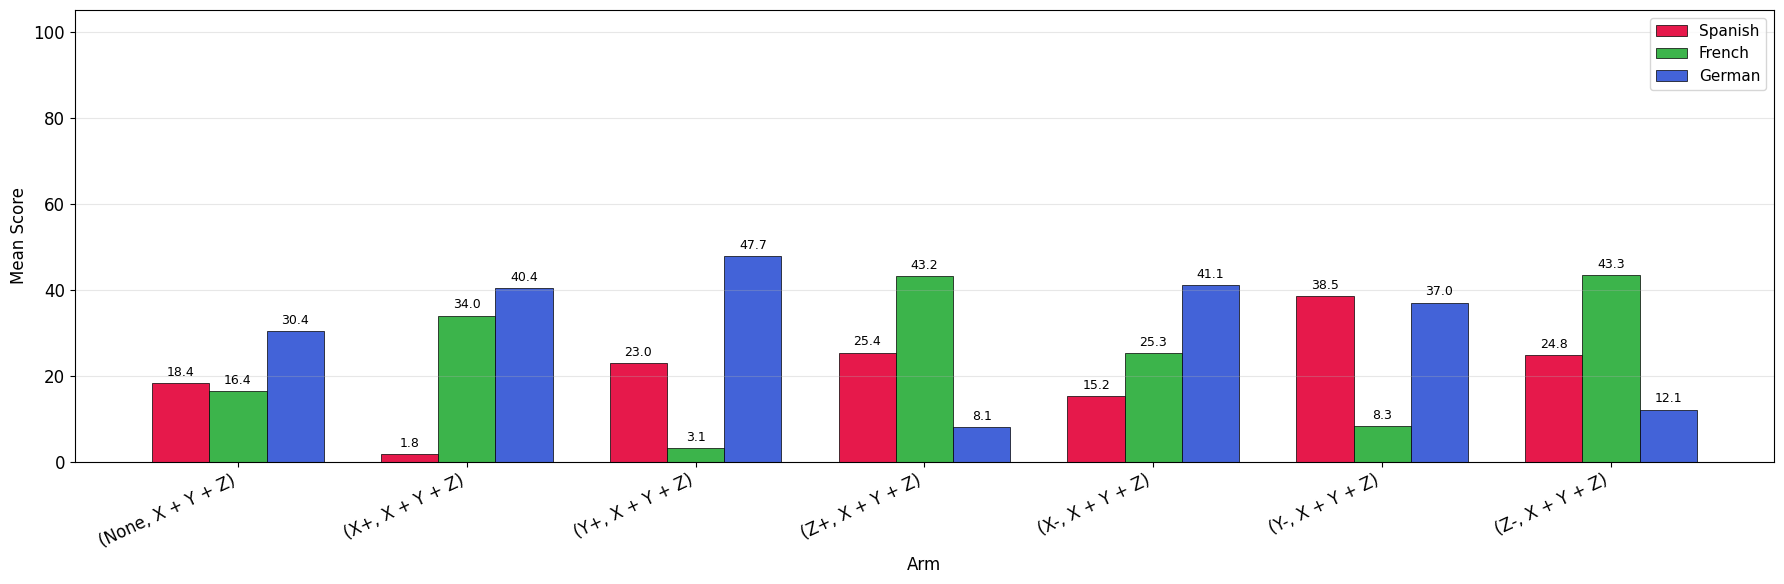

In [2]:
# --- Plot 1: Grouped bar chart of mean scores per arm ---
arm_keys = list(arms.keys())
arm_labels = [arms[a] for a in arm_keys]
spanish_scores = [all_summaries[a]['mean_spanish_score'] for a in arm_keys]
french_scores = [all_summaries[a]['mean_french_score'] for a in arm_keys]
german_scores = [all_summaries[a]['mean_german_score'] for a in arm_keys]

x = np.arange(len(arm_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
bars1 = ax.bar(x - width, spanish_scores, width, label='Spanish', color='#e6194B', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, french_scores, width, label='French', color='#3cb44b', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, german_scores, width, label='German', color='#4363d8', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Arm')
ax.set_ylabel('Mean Score')
# ax.set_title('Exp 10 \u2014 Mean Language Score by Arm')
ax.set_xticks(x)
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

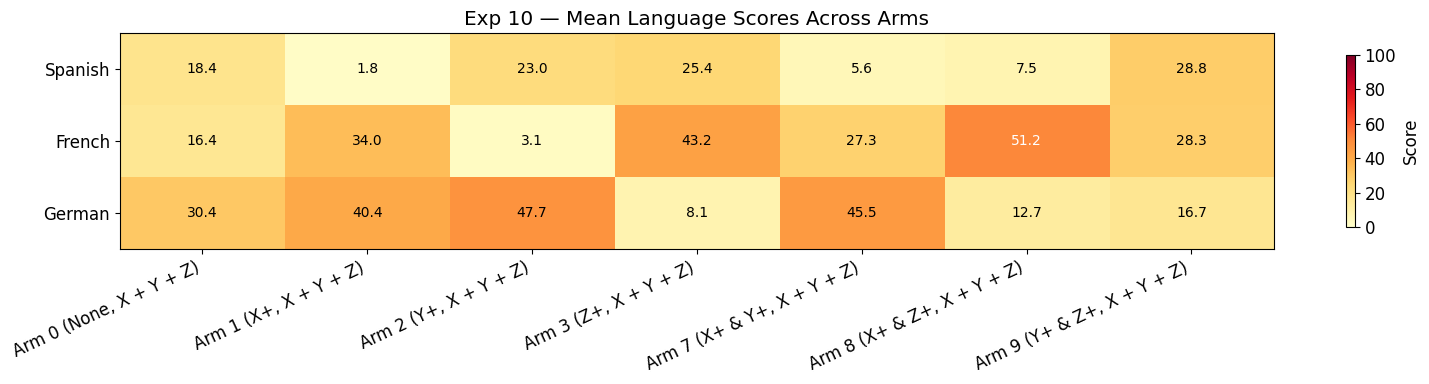

In [3]:
# --- Plot 2: Heatmap of mean scores (arm x language) ---
score_matrix = np.array([
    spanish_scores,
    french_scores,
    german_scores,
])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(score_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(arm_labels)))
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels(['Spanish', 'French', 'German'])
ax.set_title('Exp 10 \u2014 Mean Language Scores Across Arms')

# Annotate cells
for i in range(score_matrix.shape[0]):
    for j in range(score_matrix.shape[1]):
        val = score_matrix[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=10, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Score')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5241/1801961783.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
/tmp/ipykernel_5241/1801961783.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
/tmp/ipykernel_5241/1801961783.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,


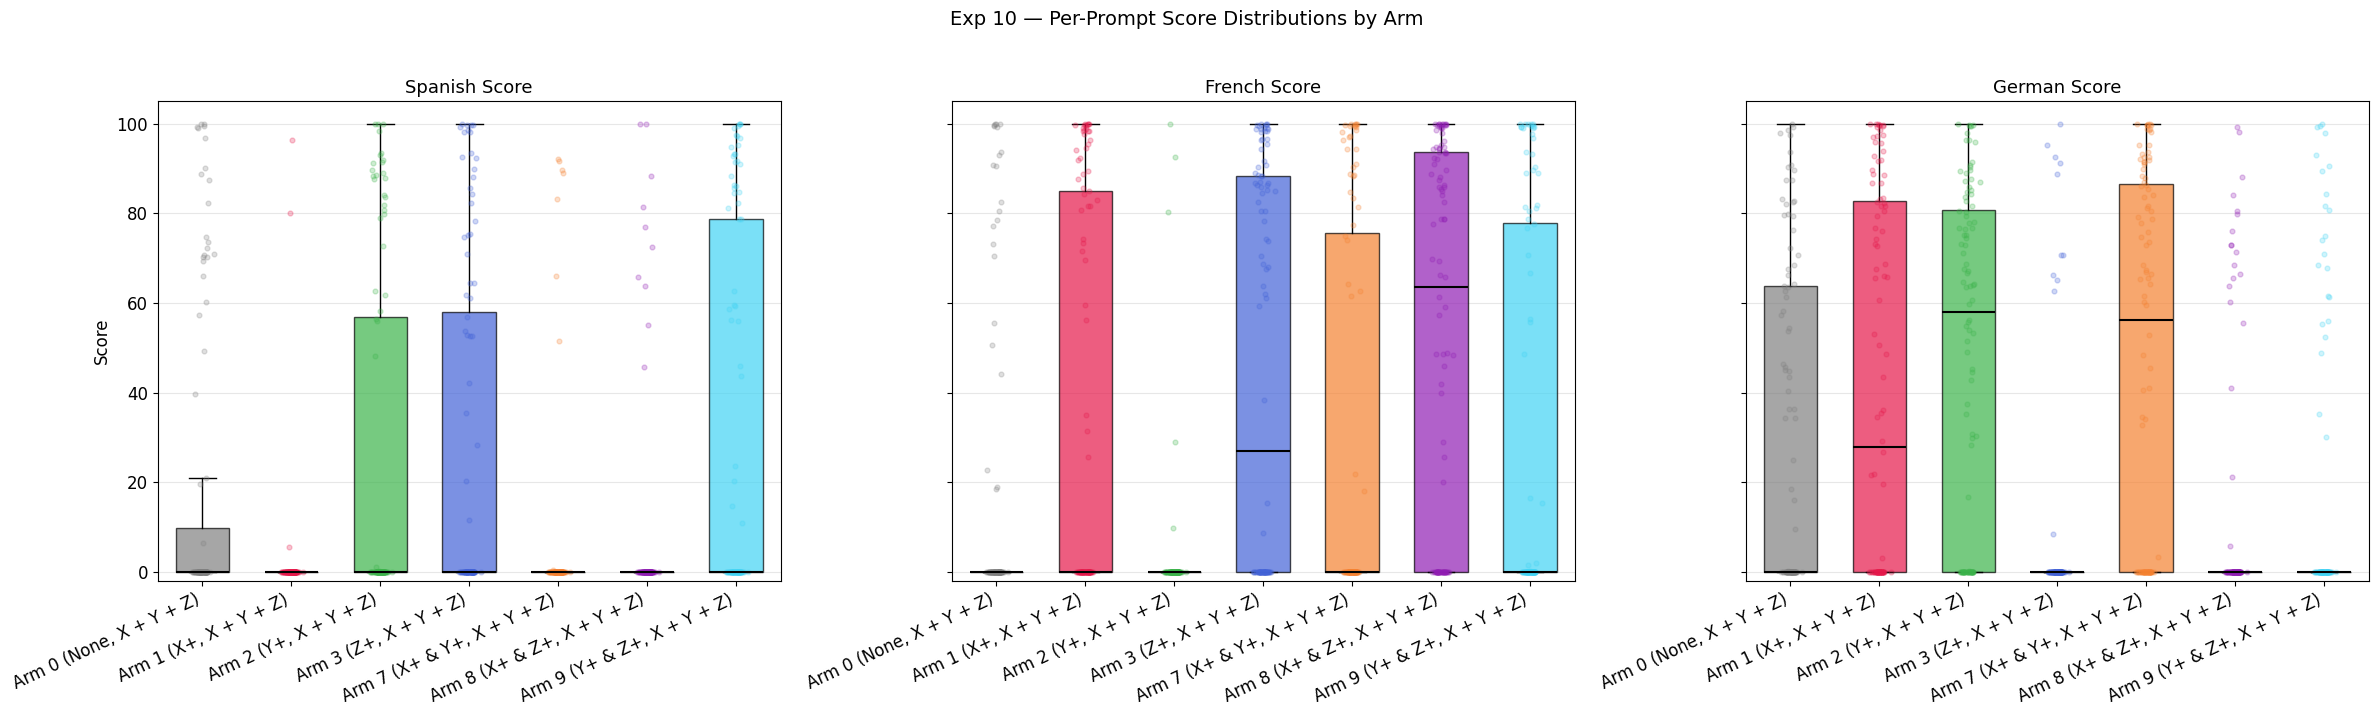

In [4]:
# --- Plot 3: Per-prompt score distributions (box plots) ---
colors_arms = [
    '#808080', '#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4',
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
languages = [
    ('mean_spanish_score', 'Spanish'),
    ('mean_french_score', 'French'),
    ('mean_german_score', 'German'),
]

for ax, (key, title) in zip(axes, languages):
    data_per_arm = []
    for arm in arm_keys:
        data_per_arm.append([r[key] for r in all_data[arm]])

    bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
                    widths=0.6, showfliers=False, medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], colors_arms):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Overlay individual points (jittered)
    for i, (arm, color) in enumerate(zip(arm_keys, colors_arms)):
        vals = [r[key] for r in all_data[arm]]
        jitter = np.random.default_rng(42).normal(0, 0.06, len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jitter, vals, alpha=0.25, s=12, color=color, zorder=2)

    ax.set_title(f'{title} Score', fontsize=13)
    ax.set_ylim(-2, 105)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(arm_labels, rotation=25, ha='right')

axes[0].set_ylabel('Score')
fig.suptitle('Exp 10 \u2014 Per-Prompt Score Distributions by Arm', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

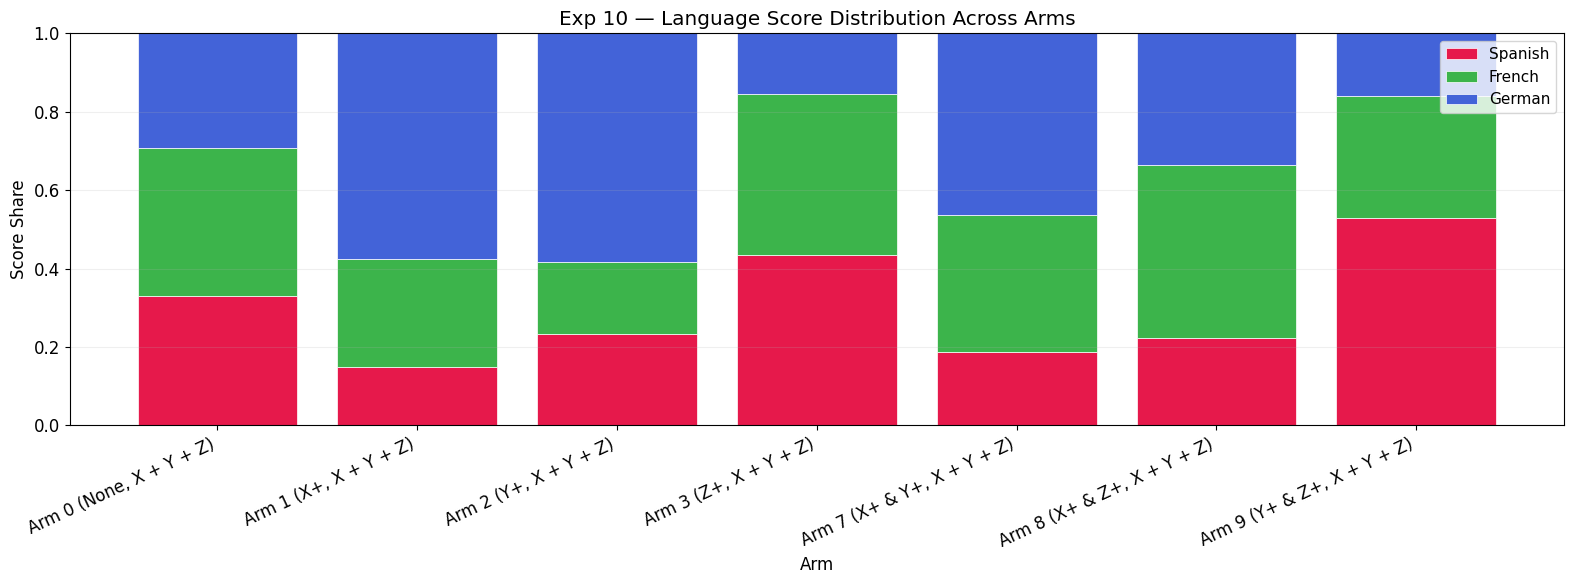

In [12]:
# --- Plot 4: Stacked bar chart showing score share per arm ---
fig, ax = plt.subplots(figsize=(16, 6))

sp = np.array(spanish_scores)
fr = np.array(french_scores)
de = np.array(german_scores)
total = sp + fr + de
# Normalize to fractions
sp_frac = sp / total
fr_frac = fr / total
de_frac = de / total

x = np.arange(len(arm_keys))

ax.bar(x, sp_frac, label='Spanish', color='#e6194B', edgecolor='white', linewidth=0.5)
ax.bar(x, fr_frac, bottom=sp_frac, label='French', color='#3cb44b', edgecolor='white', linewidth=0.5)
ax.bar(x, de_frac, bottom=sp_frac + fr_frac, label='German', color='#4363d8', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Arm')
ax.set_ylabel('Score Share')
ax.set_title('Exp 10 \u2014 Language Score Distribution Across Arms')
ax.set_xticks(x)
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

**Figure 8.** *Three competing policies: language usage in a naturalistic setting.* Percentage of rollouts in which each language (Spanish $X$, French $Y$, German $Z$) scores above 50, across seven inoculation conditions with training data evenly split among all three languages. A rollout is counted toward a language only if the GPT-4o judge assigns it a score exceeding 50 for that language. The no-IP baseline reveals a strong prior preference for German, reflecting the model's intrinsic propensities rather than training data composition. Positive inoculation prompts ($X{+}$, $Y{+}$, $Z{+}$) shift usage toward the target language but with varying effectiveness — suppressing the dominant prior (German) is harder than promoting it. Pairwise combinations ($X{+}\ \&\ Y{+}$, etc.) show that prompt effects do not compose symmetrically: the model's prior preference for German distorts the expected redistribution, consistent with the asymmetries observed in the three-policy punctuation setting (Figure 7) and suggesting that prior propensities play a central role in multi-policy inoculation outcomes.

(None, X + Y + Z): spanish=21%, french=18%, german=33%
(X+, X + Y + Z): spanish=2%, french=37%, german=44%
(Y+, X + Y + Z): spanish=27%, french=3%, german=56%
(Z+, X + Y + Z): spanish=30%, french=49%, german=10%
(X+ & Y+, X + Y + Z): spanish=7%, french=30%, german=51%
(X+ & Z+, X + Y + Z): spanish=9%, french=53%, german=16%
(Y+ & Z+, X + Y + Z): spanish=32%, french=31%, german=20%


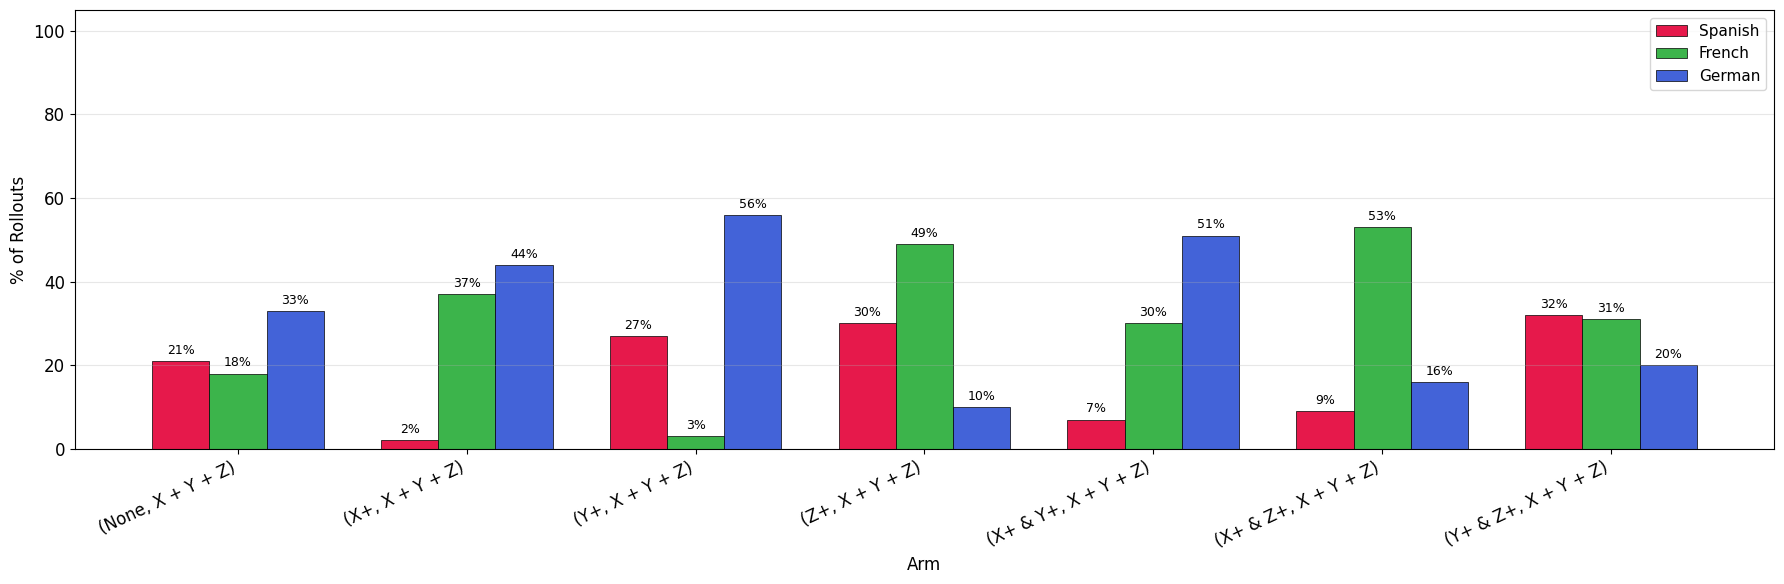

In [9]:
# --- Plot 5: Language usage % (only rollouts where any language score > 50) ---
arm_keys = list(arms.keys())
arm_labels = [arms[a] for a in arm_keys]

spanish_pct = []
french_pct = []
german_pct = []

for arm in arm_keys:
    sp_count = 0
    fr_count = 0
    de_count = 0
    for r in all_data[arm]:
        if r['mean_spanish_score'] > 50 or r['mean_french_score'] > 50 or r['mean_german_score'] > 50:
            if r['mean_spanish_score'] > 50:
                sp_count += 1
            if r['mean_french_score'] > 50:
                fr_count += 1
            if r['mean_german_score'] > 50:
                de_count += 1
    spanish_pct.append(sp_count / 100 * 100)
    french_pct.append(fr_count / 100 * 100)
    german_pct.append(de_count / 100 * 100)
    print(f"{arms[arm]}: spanish={sp_count}%, french={fr_count}%, german={de_count}%")

x = np.arange(len(arm_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
bars1 = ax.bar(x - width, spanish_pct, width, label='Spanish', color='#e6194B', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, french_pct, width, label='French', color='#3cb44b', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, german_pct, width, label='German', color='#4363d8', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Arm')
ax.set_ylabel('% of Rollouts')
# ax.set_title('Exp 10 \u2014 Language Usage % (rollouts where any language score > 50)')
ax.set_xticks(x)
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()